# RT-DETR-L Training Notebook
Notebook thu nghiem backbone RT-DETR-L voi setting tuong tu YOLO de so sanh augmentation.

## 1. Thiet lap moi truong va thu vien
Cai dat/nhap cac thu vien can thiet cho RT-DETR-L va cac thu vien lien quan.

In [ ]:
!pip install pillow==10.2.0
# !pip install -U ultralytics huggingface_hub torch torchvision torchaudio opencv-python matplotlib tqdm pyyaml numpy
!pip install ultralytics huggingface_hub torch torchvision torchaudio opencv-python matplotlib tqdm pyyaml numpy

In [ ]:
# download dataset tu Google Drive
!pip install -q gdown

import gdown
import zipfile
import os

FILE_ID = "1bvFqlR1xyChacZ8O2uVn7l8TtD3-ezPX"
ZIP_PATH = "/content/dataset.zip"
EXTRACT_PATH = "/content/dataset"

# download
gdown.download(f"https://drive.google.com/uc?id={FILE_ID}", ZIP_PATH, quiet=False)

# unzip
os.makedirs(EXTRACT_PATH, exist_ok=True)
with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Dataset ready:", EXTRACT_PATH)

Downloading...
From (original): https://drive.google.com/uc?id=16WtuzZvxvLa_d6yPu7SpfEUO7bh7Gu9i
From (redirected): https://drive.google.com/uc?id=16WtuzZvxvLa_d6yPu7SpfEUO7bh7Gu9i&confirm=t&uuid=499cdc3e-4167-4324-8707-d6892cede0ae
To: /content/dataset.zip
100%|██████████| 1.51G/1.51G [00:09<00:00, 155MB/s]


Dataset ready: /content/dataset


In [ ]:
import os
import yaml
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from ultralytics import RTDETR

## 2. Cau hinh backbone RT-DETR-L voi setting tuong tu YOLO
Tao cau hinh hyperparameters de so sanh cong bang giua cac augmentation.

In [ ]:
# DATA_ROOT = "/content/drive/MyDrive/DAT/CAMO_Dataset_Full"
DATA_ROOT = "/content/dataset/COD10K-datasets"
DATA_ROOT_SMM = "/content/dataset_smm"
USE_SMM = False

PROJECT_DIR = "DAT"
RUN_NAME = "rtdetr_l_camo_fs"
MODEL_NAME = "rtdetr-l.pt"

## 3. Nap du lieu va pipeline augmentation tuy chinh
Chon dataset (goc hoac da augment offline) va dinh nghia pipeline tuy chinh neu can.

In [ ]:
DATA_ROOT_ACTIVE = DATA_ROOT_SMM if USE_SMM else DATA_ROOT

assert os.path.exists(f"{DATA_ROOT_ACTIVE}/data.yaml"), "Khong thay data.yaml"
assert os.path.exists(f"{DATA_ROOT_ACTIVE}/train/images"), "Thieu train/images"
assert os.path.exists(f"{DATA_ROOT_ACTIVE}/train/labels"), "Thieu train/labels"
assert os.path.exists(f"{DATA_ROOT_ACTIVE}/val/images"), "Thieu val/images"
assert os.path.exists(f"{DATA_ROOT_ACTIVE}/val/labels"), "Thieu val/labels"

print("Dataset OK:", DATA_ROOT_ACTIVE)

yaml_path = f"{DATA_ROOT_ACTIVE}/data.yaml"
with open(yaml_path, "r") as f:
    data_yaml = yaml.safe_load(f)

data_yaml["path"] = DATA_ROOT_ACTIVE
data_yaml["train"] = "train/images"
data_yaml["val"] = "val/images"

with open(yaml_path, "w") as f:
    yaml.safe_dump(data_yaml, f, default_flow_style=False)

print("Da cap nhat data.yaml:", yaml_path)

# Pipeline augmentation tuy chinh (placeholder).
# Neu dung SMM offline, chi can set USE_SMM=True va data root tuong ung.
# Neu muon them mixup/cutmix tu code, ban se chen vao day.

def custom_augment(img):
    return img

Dataset OK: /content/dataset/COD10K-datasets
Da cap nhat data.yaml: /content/dataset/COD10K-datasets/data.yaml


## 4. DataLoader va kiem tra batch
Khoi tao DataLoader toi thieu va xem nhanh mot batch de kiem tra augmentation.

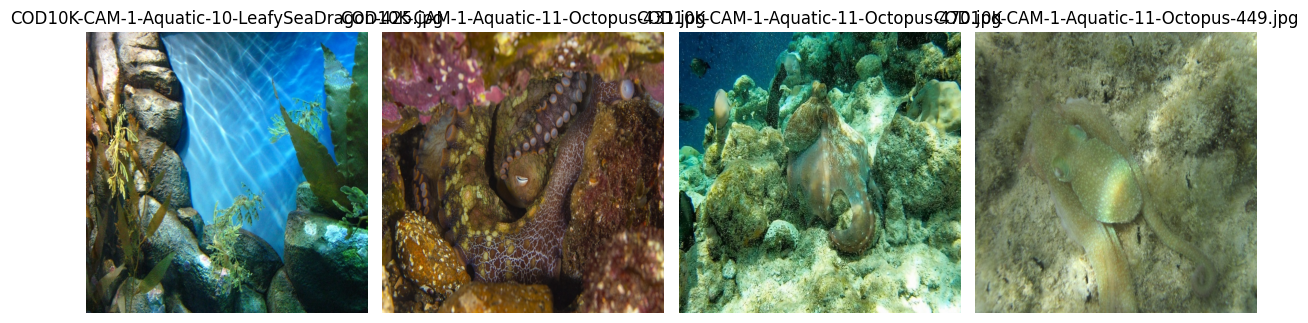

In [ ]:
class YoloFolderDataset(Dataset):
    def __init__(self, img_dir, augment=None, limit=None):
        self.img_paths = sorted([os.path.join(img_dir, p) for p in os.listdir(img_dir) if p.endswith(".jpg")])
        if limit:
            self.img_paths = self.img_paths[:limit]
        self.augment = augment

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.augment:
            img = self.augment(img)
        img = cv2.resize(img, (640, 640))
        img = img.astype(np.float32) / 255.0
        img = np.transpose(img, (2, 0, 1))
        return img, img_path

train_img_dir = os.path.join(DATA_ROOT_ACTIVE, "train", "images")
train_ds = YoloFolderDataset(train_img_dir, augment=custom_augment, limit=64)
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)

batch, paths = next(iter(train_loader))

fig, axes = plt.subplots(1, 4, figsize=(12, 4))
for i in range(4):
    img = batch[i].permute(1, 2, 0).cpu().numpy()
    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(os.path.basename(paths[i]))
plt.tight_layout()

## 5. Khoi tao model RT-DETR-L va optimizer
Tao model va san sang cho buoc train.

In [ ]:
model = RTDETR(MODEL_NAME)
print("Model loaded:", MODEL_NAME)

Model loaded: rtdetr-l.pt


## 6. Chay thu mot vong train ngan voi augmentation
Dung so epoch nho de kiem tra pipeline; sau do tang len EPOCHS khi chay that.

In [ ]:
results = model.train(
    data=f"{DATA_ROOT_ACTIVE}/data.yaml",
    epochs=100,
    imgsz=640,
    batch=64,
    patience=30,
    optimizer="AdamW",
    lr0=1e-4,
    device=0,
    workers=4,
    project=PROJECT_DIR,
    name=RUN_NAME,
    verbose=True,
    plots=False,
    seed=42,
    deterministic=True,
    # Giu cac setting giong YOLO de so sanh cong bang
    auto_augment=None,
    close_mosaic=0,

    hsv_h=0.0,
    hsv_s=0.0,
    hsv_v=0.0,

    degrees=0.0,
    translate=0.0,
    scale=0.0,
    shear=0.0,
    perspective=0.0,

    fliplr=0.0,
    flipud=0.0,

    mosaic=0.0,
    mixup=0.0,
    copy_paste=0.0,
    erasing=0.0,
    augmentations=[],
)
print("Train done:", results)

Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, augmentations=[], auto_augment=None, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/COD10K-datasets/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.0, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=rtdetr_l_camo_fs, nbs=64, nms=False, opset=None, optimize=False, o

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      1/100      38.6G      1.034      1.486      1.433         44        640: 100% ━━━━━━━━━━━━ 95/95 1.6it/s 58.6s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 1.1it/s 14.0s
                   all       2026       2365   8.77e-06     0.0201   5.19e-05   1.31e-05

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      2/100      23.6G     0.7771      1.985     0.9915         34        640: 0% ──────────── 0/95  0.6s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      2/100      23.6G     0.6592      2.185     0.7039         34        640: 100% ━━━━━━━━━━━━ 95/95 1.9it/s 51.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 1.8it/s 9.1s
                   all       2026       2365   6.19e-05     0.0366    0.00014   5.01e-05

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      3/100      23.7G     0.5218      2.537     0.5571         34        640: 0% ──────────── 0/95  0.6s

...

     98/100      23.6G    0.03898    0.09976    0.03835         40        640: 100% ━━━━━━━━━━━━ 95/95 1.9it/s 49.8s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 1.7it/s 9.5s
                   all       2026       2365      0.474      0.244      0.244      0.149

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
     99/100      23.7G    0.03934     0.1307    0.04189         39        640: 0% ──────────── 0/95  0.6s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


     99/100      23.7G    0.03834    0.09775    0.03824         37        640: 100% ━━━━━━━━━━━━ 95/95 1.9it/s 49.9s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 1.6it/s 9.7s
                   all       2026       2365      0.512      0.244      0.247      0.151

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
    100/100      23.5G    0.07098     0.1296    0.06074         41        640: 0% ──────────── 0/95  0.5s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


    100/100      23.5G    0.03912    0.09976    0.03863         40        640: 100% ━━━━━━━━━━━━ 95/95 1.9it/s 49.7s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 1.7it/s 9.5s
                   all       2026       2365      0.496      0.246      0.246       0.15

100 epochs completed in 1.722 hours.
Optimizer stripped from /content/runs/detect/DAT/rtdetr_l_camo_fs/weights/last.pt, 66.5MB
Optimizer stripped from /content/runs/detect/DAT/rtdetr_l_camo_fs/weights/best.pt, 66.5MB

Validating /content/runs/detect/DAT/rtdetr_l_camo_fs/weights/best.pt...
Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
rt-detr-l summary: 310 layers, 32,125,535 parameters, 0 gradients, 103.7 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 1.8it/s 8.7s
                   all       2026       2365      0.472      0.257      0

## 7. Danh gia nhanh tren batch validation
Kiem tra nhanh mAP va loss tren validation.

In [ ]:
BEST_WEIGHTS = f"/content/runs/detect/{PROJECT_DIR}/{RUN_NAME}/weights/best.pt"

assert os.path.exists(BEST_WEIGHTS), f"Khong thay {BEST_WEIGHTS}"

model = RTDETR(BEST_WEIGHTS)

last_metrics = model.val(
    data=f"{DATA_ROOT_ACTIVE}/data.yaml",
    split="val",
    verbose=False,
    plots=False,
)

print(f"mAP@50    : {last_metrics.box.map50:.4f}")
print(f"mAP@50-95 : {last_metrics.box.map:.4f}")

Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
rt-detr-l summary: 310 layers, 32,125,535 parameters, 0 gradients, 103.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2939.8±844.7 MB/s, size: 245.2 KB)
val: Scanning /content/dataset/COD10K-datasets/val/labels.cache... 2026 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2026/2026 849.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 127/127 8.7it/s 14.6s
                   all       2026       2365      0.457      0.257      0.253      0.155
Speed: 0.5ms preprocess, 4.8ms inference, 0.0ms loss, 0.2ms postprocess per image
mAP@50    : 0.2525
mAP@50-95 : 0.1551


## 8. Luu checkpoint va log ket qua
Luu thong tin ket qua va copy run ra Drive neu can.

In [ ]:
import json
import shutil

run_dir = f"/content/runs/detect/{PROJECT_DIR}/{RUN_NAME}"
metrics_path = os.path.join(run_dir, "metrics.json")

if "last_metrics" in globals():
    with open(metrics_path, "w") as f:
        json.dump(
            {
                "map50": float(last_metrics.box.map50),
                "map50_95": float(last_metrics.box.map),
            },
            f,
            indent=2,
        )
    print("Da ghi metrics:", metrics_path)

Da ghi metrics: /content/runs/detect/DAT/rtdetr_l_camo_fs/metrics.json


In [ ]:
from huggingface_hub import login, HfApi

login(token="YOUR_HUGGINGFACE_TOKEN")  # dan token WRITE

api = HfApi()
repo_id = "Thanhdat3010/rtdetr-l-COD10K-Baseline"  # doi neu can

api.create_repo(repo_id=repo_id, exist_ok=True, repo_type="model")

run_dir = f"/content/runs/detect/{PROJECT_DIR}/{RUN_NAME}"
api.upload_folder(
    folder_path=run_dir,
    repo_id=repo_id,
    repo_type="model"
)

print("Push HuggingFace xong:", repo_id)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...l_camo_fs/weights/best.pt:   1%|          |  526kB / 66.5MB            

  ...l_camo_fs/weights/last.pt:   6%|5         | 3.68MB / 66.5MB            

Push HuggingFace xong: Thanhdat3010/rtdetr-l-COD10K-Baseline
